# 03 — Waypoint Strategy corrigé

Objectif :
- ajouter une stratégie de waypoints au planner physique ;
- contourner l'île par la gauche ou par la droite ;
- choisir automatiquement un côté selon le vent ;
- tester plusieurs seeds et scénarios ;
- visualiser les trajectoires.

Corrections intégrées :
- imports compatibles avec le dépôt réel ;
- création correcte de l'environnement : `SailingEnv(**get_wind_scenario(name))` ;
- utilisation correcte de `env.world_map` ;
- suppression de `env.clone()`, remplacé par `copy.deepcopy(env)` pour les rollouts du notebook ;
- cellules autonomes, avec fonctions robustes et sans variables non définies.


## 1. Imports et détection robuste du dépôt

In [1]:

from pathlib import Path
import os
import sys
import copy
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Si la détection automatique échoue, renseigne ici le chemin absolu du dépôt.
# Exemple Windows :
# MANUAL_REPO_ROOT = r"C:\\Users\\...\\stable_v2_RL_sailing_challenge"
MANUAL_REPO_ROOT = None


def safe_cwd():
    try:
        return Path.cwd().resolve()
    except FileNotFoundError:
        return Path.home().resolve()


def find_repo_root(manual_root=None):
    candidates = []

    if manual_root:
        candidates.append(Path(manual_root).expanduser().resolve())

    cwd = safe_cwd()
    candidates.extend([cwd] + list(cwd.parents))

    candidates.extend([
        Path("/mnt/data/stable_v2_RL_sailing_challenge"),
        Path("/mnt/data/sailing_repo/stable_v2_RL_sailing_challenge"),
        Path("/mnt/data/sailing/stable_v2_RL_sailing_challenge"),
        Path.home() / "stable_v2_RL_sailing_challenge",
    ])

    seen = set()
    for p in candidates:
        if p in seen:
            continue
        seen.add(p)

        if (p / "src" / "env_sailing.py").exists():
            return p

    raise FileNotFoundError(
        "Impossible de trouver le dépôt. "
        "Place ce notebook dans le dépôt ou renseigne MANUAL_REPO_ROOT."
    )


REPO_ROOT = find_repo_root(MANUAL_REPO_ROOT)
SRC_DIR = REPO_ROOT / "src"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT =", REPO_ROOT)
print("SRC_DIR   =", SRC_DIR)


REPO_ROOT = /home/onyxia/work/stable_v2_RL_sailing_challenge
SRC_DIR   = /home/onyxia/work/stable_v2_RL_sailing_challenge/src


In [2]:

from src.env_sailing import SailingEnv
from src.wind_scenarios import get_wind_scenario, WIND_SCENARIOS
from src.sailing_physics import calculate_sailing_efficiency

print("Imports OK.")
print("Scénarios disponibles :", list(WIND_SCENARIOS.keys()))


Imports OK.
Scénarios disponibles : ['training_1', 'training_2', 'training_3']


## 2. Création de l'environnement

Dans le dépôt réel, on doit créer l'environnement comme suit :

```python
env = SailingEnv(**get_wind_scenario(name))
```


In [3]:

SCENARIO_NAME = "training_1"


def make_env(scenario_name=SCENARIO_NAME, seed=0, static_wind=True, render_mode="rgb_array", show_full_trajectory=True):
    env = SailingEnv(
        **get_wind_scenario(scenario_name),
        static_wind=static_wind,
        render_mode=render_mode,
        show_full_trajectory=show_full_trajectory,
    )
    obs, info = env.reset(seed=seed)
    return env, obs, info


env, obs, info = make_env(SCENARIO_NAME, seed=0)

print("Scenario:", SCENARIO_NAME)
print("Observation shape:", obs.shape)
print("Position:", env.position)
print("Velocity:", env.velocity)
print("Goal:", env.goal_position)
print("World map shape:", env.world_map.shape)
print("Wind field shape:", env.wind_field.shape)


Scenario: training_1
Observation shape: (49158,)
Position: [64  0]
Velocity: [0. 0.]
Goal: [ 64 127]
World map shape: (128, 128)
Wind field shape: (128, 128, 2)


## 3. Fonctions utilitaires : observation, collision, distances

In [4]:

def parse_observation(observation, grid_size=(128, 128)):
    W, H = grid_size
    observation = np.asarray(observation, dtype=np.float32)

    n_wind = W * H * 2
    n_world = W * H
    expected_len = 6 + n_wind + n_world

    if observation.shape[0] != expected_len:
        raise ValueError(
            f"Unexpected observation length: {observation.shape[0]} != {expected_len}"
        )

    position = observation[0:2].astype(np.float32)
    velocity = observation[2:4].astype(np.float32)
    local_wind = observation[4:6].astype(np.float32)
    wind_field = observation[6:6+n_wind].reshape(H, W, 2)
    world_map = observation[6+n_wind:6+n_wind+n_world].reshape(H, W)

    return {
        "position": position,
        "velocity": velocity,
        "local_wind": local_wind,
        "wind_field": wind_field,
        "world_map": world_map,
        "x": float(position[0]),
        "y": float(position[1]),
        "vx": float(velocity[0]),
        "vy": float(velocity[1]),
        "wx": float(local_wind[0]),
        "wy": float(local_wind[1]),
    }


def is_collision_xy(x, y, world):
    x = int(np.clip(round(float(x)), 0, world.shape[1] - 1))
    y = int(np.clip(round(float(y)), 0, world.shape[0] - 1))
    return bool(world[y, x] == 1)


def distance_to_goal(position, goal=np.array([64, 127])):
    position = np.asarray(position, dtype=float)
    goal = np.asarray(goal, dtype=float)
    return float(np.linalg.norm(position - goal))


def distance_to_island(position, world):
    position = np.asarray(position, dtype=float)

    ys, xs = np.where(world == 1)
    if len(xs) == 0:
        return np.inf

    d2 = (xs - position[0])**2 + (ys - position[1])**2
    return float(np.sqrt(d2.min()))


state = parse_observation(obs, env.grid_size)
print("Parsed state:", {k: state[k] for k in ["x", "y", "vx", "vy", "wx", "wy"]})
print("Collision start:", is_collision_xy(64, 0, env.world_map))
print("Collision island center:", is_collision_xy(64, 60, env.world_map))


Parsed state: {'x': 64.0, 'y': 0.0, 'vx': 0.0, 'vy': 0.0, 'wx': -5.455411434173584, 'wy': 8.380840301513672}
Collision start: False
Collision island center: True


## 4. Carte et actions

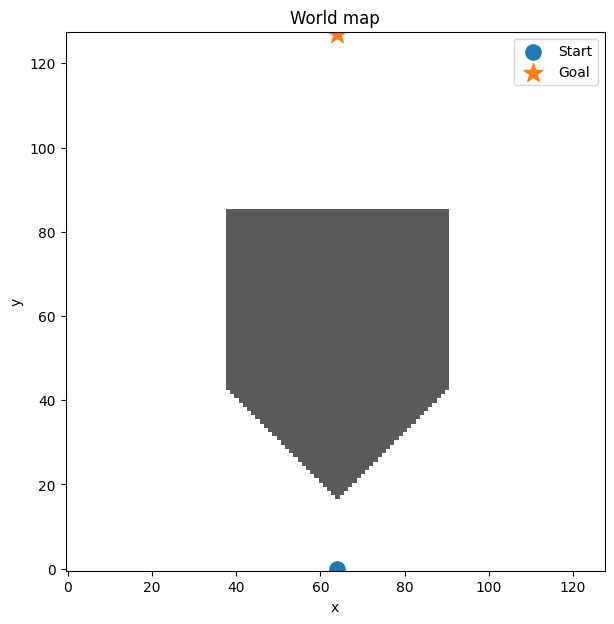

,action,name,dx,dy
0,0,North,0,1
1,1,North-East,1,1
2,2,East,1,0
3,3,South-East,1,-1
4,4,South,0,-1
5,5,South-West,-1,-1
6,6,West,-1,0
7,7,North-West,-1,1
8,8,Stay,0,0


In [5]:

ACTION_NAMES = {
    0: "North",
    1: "North-East",
    2: "East",
    3: "South-East",
    4: "South",
    5: "South-West",
    6: "West",
    7: "North-West",
    8: "Stay",
}

plt.figure(figsize=(7, 7))
plt.imshow(env.world_map, origin="lower", cmap="Greys", alpha=0.65)
plt.scatter([64], [0], s=120, marker="o", label="Start")
plt.scatter([64], [127], s=200, marker="*", label="Goal")
plt.title("World map")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

rows = []
for a in range(9):
    d = env._action_to_direction(a)
    rows.append({"action": a, "name": ACTION_NAMES[a], "dx": int(d[0]), "dy": int(d[1])})
display(pd.DataFrame(rows))


## 5. Waypoints pour contourner l'île

On construit deux familles de waypoints :
- côté gauche ;
- côté droit.

Le choix du côté pourra dépendre du vent.


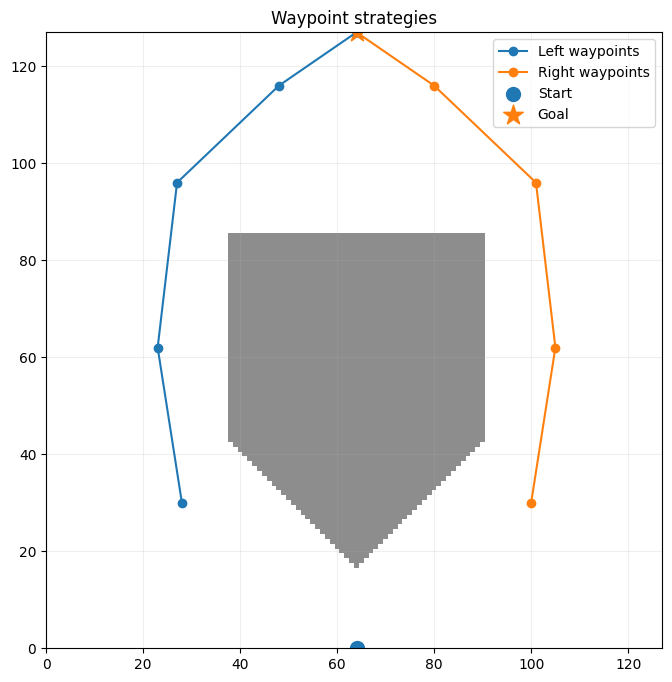

In [6]:

GOAL = np.array([64.0, 127.0], dtype=np.float32)

LEFT_WAYPOINTS = np.array([
    [28.0, 30.0],
    [23.0, 62.0],
    [27.0, 96.0],
    [48.0, 116.0],
    [64.0, 127.0],
], dtype=np.float32)

RIGHT_WAYPOINTS = np.array([
    [100.0, 30.0],
    [105.0, 62.0],
    [101.0, 96.0],
    [80.0, 116.0],
    [64.0, 127.0],
], dtype=np.float32)


def plot_waypoints(env):
    plt.figure(figsize=(8, 8))
    plt.imshow(env.world_map, origin="lower", cmap="Greys", alpha=0.45)

    plt.plot(LEFT_WAYPOINTS[:, 0], LEFT_WAYPOINTS[:, 1], marker="o", label="Left waypoints")
    plt.plot(RIGHT_WAYPOINTS[:, 0], RIGHT_WAYPOINTS[:, 1], marker="o", label="Right waypoints")

    plt.scatter([64], [0], s=100, marker="o", label="Start")
    plt.scatter([64], [127], s=220, marker="*", label="Goal")

    plt.xlim(0, 127)
    plt.ylim(0, 127)
    plt.title("Waypoint strategies")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


plot_waypoints(env)


## 6. Choix automatique gauche/droite

L'idée :
- comparer les couloirs de vent gauche et droit ;
- privilégier le couloir avec le meilleur vent nord moyen ;
- en cas d'égalité, utiliser le vent local au départ.


In [7]:

def choose_side_from_wind(wind_field, margin=0.05):
    # wind_field shape: (H, W, 2), with components wx, wy.
    # Corridors chosen to avoid the central island.
    left_corridor = wind_field[15:112, 12:40, :]
    right_corridor = wind_field[15:112, 88:116, :]

    # Strong positive y wind is favorable for going North.
    left_north = float(np.mean(left_corridor[..., 1]))
    right_north = float(np.mean(right_corridor[..., 1]))

    # Lateral wind too strong can make route less stable.
    left_lateral_penalty = 0.10 * abs(float(np.mean(left_corridor[..., 0])))
    right_lateral_penalty = 0.10 * abs(float(np.mean(right_corridor[..., 0])))

    left_score = left_north - left_lateral_penalty
    right_score = right_north - right_lateral_penalty

    if abs(left_score - right_score) <= margin:
        wx_start = float(wind_field[0, 64, 0])
        side = "RIGHT" if wx_start >= 0 else "LEFT"
    else:
        side = "LEFT" if left_score > right_score else "RIGHT"

    return side, {
        "left_score": left_score,
        "right_score": right_score,
        "left_north": left_north,
        "right_north": right_north,
    }


side, side_info = choose_side_from_wind(env.wind_field)
print("Chosen side:", side)
print(side_info)


Chosen side: LEFT
{'left_score': -0.8755264740488712, 'right_score': -7.28408167747919, 'left_north': 0.033016913566708245, 'right_north': -7.0331530633297605}


## 7. Gestionnaire de waypoints

In [8]:

class WaypointManager:
    def __init__(self, side="LEFT", radius=12.0):
        self.side = side
        self.radius = float(radius)
        self.index = 0
        self.waypoints = LEFT_WAYPOINTS if side == "LEFT" else RIGHT_WAYPOINTS

    def current(self):
        return self.waypoints[min(self.index, len(self.waypoints) - 1)]

    def update(self, position):
        position = np.asarray(position, dtype=float)

        if self.index >= len(self.waypoints) - 1:
            return

        current = self.current()
        dist = np.linalg.norm(position - current)

        if dist <= self.radius:
            self.index += 1

        # Règles de sécurité : si le bateau est déjà haut, avancer dans les waypoints.
        y = position[1]
        if y > 45 and self.index < 1:
            self.index = 1
        if y > 82 and self.index < 2:
            self.index = 2
        if y > 108 and self.index < 3:
            self.index = 3

    def as_dict(self):
        return {
            "side": self.side,
            "radius": self.radius,
            "index": self.index,
            "current": self.current().tolist(),
        }


manager = WaypointManager(side=side, radius=12.0)
print(manager.as_dict())


{'side': 'LEFT', 'radius': 12.0, 'index': 0, 'current': [28.0, 30.0]}


## 8. Score waypoint-aware

Le score combine :
- rapprochement du waypoint courant ;
- progression globale vers le goal ;
- vitesse vers le nord ;
- pénalités près de l'île et des bords.


In [9]:

def waypoint_score(position, velocity, waypoint, world):
    position = np.asarray(position, dtype=float)
    velocity = np.asarray(velocity, dtype=float)
    waypoint = np.asarray(waypoint, dtype=float)

    x, y = position
    vx, vy = velocity

    dist_wp = float(np.linalg.norm(position - waypoint))
    dist_goal = distance_to_goal(position, GOAL)
    dist_island = distance_to_island(position, world)

    score = 0.0

    # Aller vers le waypoint courant.
    score -= 1.8 * dist_wp

    # Garder une progression vers le nord et le goal.
    score += 4.0 * y
    score -= 0.20 * dist_goal

    # Favoriser vitesse nord.
    score += 6.0 * vy

    # Fort bonus si proche du waypoint.
    if dist_wp <= 10:
        score += 300.0

    # Éviter l'île avec marge.
    if dist_island < 10:
        score -= 1000.0 * (10 - dist_island)

    if is_collision_xy(x, y, world):
        score -= 1_000_000.0

    # Éviter les bords.
    if x < 4 or x > 123:
        score -= 2000.0

    # Bonus goal.
    if dist_goal < 1.5:
        score += 1_000_000.0

    return float(score)


print("Score start toward current waypoint:",
      waypoint_score(env.position, env.velocity, manager.current(), env.world_map))


Score start toward current waypoint: -109.75069649979187


## 9. Rollout d'une séquence avec waypoints

On utilise `copy.deepcopy(env)` pour simuler une séquence candidate dans ce notebook.


In [10]:

def rollout_score_waypoint(env, action_sequence, waypoint):
    cloned = copy.deepcopy(env)

    total_score = 0.0
    reached_goal = False
    stuck = False

    for j, action in enumerate(action_sequence):
        obs, reward, terminated, truncated, info = cloned.step(int(action))

        total_score += waypoint_score(
            cloned.position,
            cloned.velocity,
            waypoint,
            cloned.world_map,
        )

        if reward > 0:
            total_score += 1_000_000.0 / (1 + j)
            reached_goal = True

        if info.get("is_stuck", False):
            total_score -= 1_000_000.0
            stuck = True

        if terminated or truncated:
            break

    return float(total_score), reached_goal, stuck


for seq in [[0, 0], [1, 1], [7, 7], [8, 8]]:
    score, reached, stuck = rollout_score_waypoint(env, seq, manager.current())
    print(seq, "score=", round(score, 2), "reached=", reached, "stuck=", stuck)


[0, 0] score= -152.39 reached= False stuck= False
[1, 1] score= -162.82 reached= False stuck= False
[7, 7] score= -187.3 reached= False stuck= False
[8, 8] score= -219.5 reached= False stuck= False


## 10. Choisir une action avec le planner waypoint

In [11]:

def candidate_sequences(horizon=2):
    actions = list(range(9))

    if horizon <= 1:
        return [[a] for a in actions]

    if horizon == 2:
        return [list(seq) for seq in product(actions, repeat=2)]

    useful_actions = [0, 1, 2, 6, 7, 8]
    candidates = []

    for a in actions:
        candidates.append([a] * horizon)

    for a in actions:
        for b in useful_actions:
            candidates.append([a] + [b] * (horizon - 1))

    motifs = [
        [1, 7],
        [7, 1],
        [0, 1],
        [0, 7],
        [1, 0],
        [7, 0],
    ]

    for motif in motifs:
        seq = (motif * ((horizon + len(motif) - 1) // len(motif)))[:horizon]
        candidates.append(seq)

    unique = []
    seen = set()
    for seq in candidates:
        key = tuple(seq)
        if key not in seen:
            seen.add(key)
            unique.append(seq)

    return unique


def choose_action_waypoint(env, waypoint, horizon=2, return_debug=False):
    best_score = -np.inf
    best_action = 0
    best_seq = None
    rows = []

    for seq in candidate_sequences(horizon=horizon):
        score, reached, stuck = rollout_score_waypoint(env, seq, waypoint)

        rows.append({
            "seq": tuple(seq),
            "first_action": int(seq[0]),
            "first_action_name": ACTION_NAMES[int(seq[0])],
            "score": score,
            "reached": reached,
            "stuck": stuck,
        })

        if score > best_score:
            best_score = score
            best_action = int(seq[0])
            best_seq = tuple(seq)

    debug = pd.DataFrame(rows).sort_values("score", ascending=False)

    if return_debug:
        return best_action, best_seq, best_score, debug

    return best_action


action, seq, score, debug = choose_action_waypoint(env, manager.current(), horizon=2, return_debug=True)

print("Best action:", action, ACTION_NAMES[action])
print("Best sequence:", seq)
print("Best score:", score)
display(debug.head(10))


Best action: 0 North
Best sequence: (0, 0)
Best score: -152.385215810058


,seq,first_action,first_action_name,score,reached,stuck
0,"(0, 0)",0,North,-152.385216,False,False
1,"(0, 1)",0,North,-155.371180,False,False
9,"(1, 0)",1,North-East,-158.244800,False,False
7,"(0, 7)",0,North,-162.174269,False,False
10,"(1, 1)",1,North-East,-162.824226,False,False
16,"(1, 7)",1,North-East,-167.966081,False,False
64,"(7, 1)",7,North-West,-169.016515,False,False
63,"(7, 0)",7,North-West,-177.384821,False,False
6,"(0, 6)",0,North,-183.377606,False,False
4,"(0, 4)",0,North,-186.185261,False,False


## 11. Exécuter un épisode avec stratégie waypoint

In [12]:

def run_waypoint_episode(
    scenario_name="training_1",
    seed=0,
    horizon=2,
    wp_radius=12.0,
    max_steps=500,
    static_wind=True,
    force_side=None,
):
    env, obs, info = make_env(
        scenario_name=scenario_name,
        seed=seed,
        static_wind=static_wind,
        render_mode="rgb_array",
        show_full_trajectory=True,
    )

    parsed = parse_observation(obs, env.grid_size)

    if force_side is None:
        side, side_info = choose_side_from_wind(parsed["wind_field"])
    else:
        side = force_side
        side_info = {"forced": True}

    manager = WaypointManager(side=side, radius=wp_radius)

    trajectory = [env.position.copy()]
    actions = []
    rewards = []
    infos = []
    waypoint_indices = [manager.index]
    waypoint_targets = [manager.current().copy()]

    terminated = False
    truncated = False

    for step in range(max_steps):
        manager.update(env.position)
        waypoint = manager.current()

        action = choose_action_waypoint(env, waypoint, horizon=horizon)

        obs, reward, terminated, truncated, info = env.step(action)

        trajectory.append(env.position.copy())
        actions.append(action)
        rewards.append(float(reward))
        infos.append(info)
        waypoint_indices.append(manager.index)
        waypoint_targets.append(manager.current().copy())

        if terminated or truncated:
            break

    result = {
        "scenario": scenario_name,
        "seed": seed,
        "horizon": horizon,
        "side": side,
        "wp_radius": wp_radius,
        "steps": len(actions),
        "reward_sum": float(np.sum(rewards)),
        "discounted_score": float(np.sum(rewards) * (0.995 ** len(actions))),
        "success": bool(np.sum(rewards) > 0),
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "is_stuck": bool(infos[-1].get("is_stuck", False)) if infos else False,
        "final_position": trajectory[-1].tolist(),
        "side_info": side_info,
    }

    extra = {
        "waypoint_indices": waypoint_indices,
        "waypoint_targets": np.array(waypoint_targets),
    }

    return result, np.array(trajectory), actions, rewards, infos, env, extra


result, trajectory, actions, rewards, infos, env_run, extra = run_waypoint_episode(
    scenario_name="training_1",
    seed=0,
    horizon=2,
    wp_radius=12.0,
    static_wind=True,
)

result


{'scenario': 'training_1',
 'seed': 0,
 'horizon': 2,
 'side': 'LEFT',
 'wp_radius': 12.0,
 'steps': 55,
 'reward_sum': 100.0,
 'discounted_score': 75.90483508202912,
 'success': True,
 'terminated': True,
 'truncated': False,
 'is_stuck': False,
 'final_position': [63, 127],
 'side_info': {'left_score': -0.875526487082243,
  'right_score': -7.2840821743011475,
  'left_north': 0.033016908913850784,
  'right_north': -7.033153533935547}}

## 12. Visualiser la trajectoire waypoint

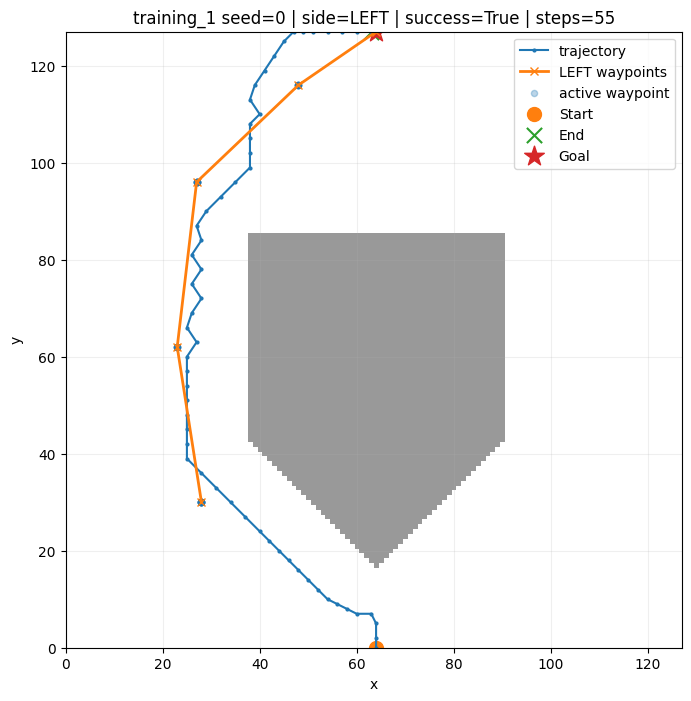

In [13]:

def plot_waypoint_trajectory(trajectory, env, side, extra=None, title=None):
    plt.figure(figsize=(8, 8))
    plt.imshow(env.world_map, origin="lower", cmap="Greys", alpha=0.4)

    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        marker="o",
        markersize=2,
        linewidth=1.5,
        label="trajectory",
    )

    wps = LEFT_WAYPOINTS if side == "LEFT" else RIGHT_WAYPOINTS
    plt.plot(wps[:, 0], wps[:, 1], marker="x", linewidth=2, label=f"{side} waypoints")

    if extra is not None and "waypoint_targets" in extra:
        targets = extra["waypoint_targets"]
        plt.scatter(targets[:, 0], targets[:, 1], s=20, alpha=0.3, label="active waypoint")

    plt.scatter([trajectory[0, 0]], [trajectory[0, 1]], s=100, marker="o", label="Start")
    plt.scatter([trajectory[-1, 0]], [trajectory[-1, 1]], s=120, marker="x", label="End")
    plt.scatter([64], [127], s=220, marker="*", label="Goal")

    plt.title(title or f"Waypoint trajectory ({side})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(0, 127)
    plt.ylim(0, 127)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


plot_waypoint_trajectory(
    trajectory,
    env_run,
    side=result["side"],
    extra=extra,
    title=f"{result['scenario']} seed={result['seed']} | side={result['side']} | success={result['success']} | steps={result['steps']}",
)


## 13. Diagnostics de l'épisode

,step,x,y,next_x,next_y,action,action_name,reward,distance_to_goal,is_stuck,wp_index,wp_x,wp_y
0,0,64.0,0.0,64.0,2.0,0,North,0.0,125.000000,False,0,28.0,30.0
1,1,64.0,2.0,64.0,5.0,0,North,0.0,122.000000,False,0,28.0,30.0
2,2,64.0,5.0,63.0,7.0,7,North-West,0.0,120.004167,False,0,28.0,30.0
3,3,63.0,7.0,60.0,7.0,6,West,0.0,120.066648,False,0,28.0,30.0
4,4,60.0,7.0,58.0,8.0,7,North-West,0.0,119.151164,False,0,28.0,30.0


,step,x,y,next_x,next_y,action,action_name,reward,distance_to_goal,is_stuck,wp_index,wp_x,wp_y
50,50,49.0,127.0,51.0,127.0,1,North-East,0.0,13.0,False,4,64.0,127.0
51,51,51.0,127.0,54.0,127.0,2,East,0.0,10.0,False,4,64.0,127.0
52,52,54.0,127.0,57.0,127.0,1,North-East,0.0,7.0,False,4,64.0,127.0
53,53,57.0,127.0,60.0,127.0,2,East,0.0,4.0,False,4,64.0,127.0
54,54,60.0,127.0,63.0,127.0,1,North-East,100.0,1.0,False,4,64.0,127.0


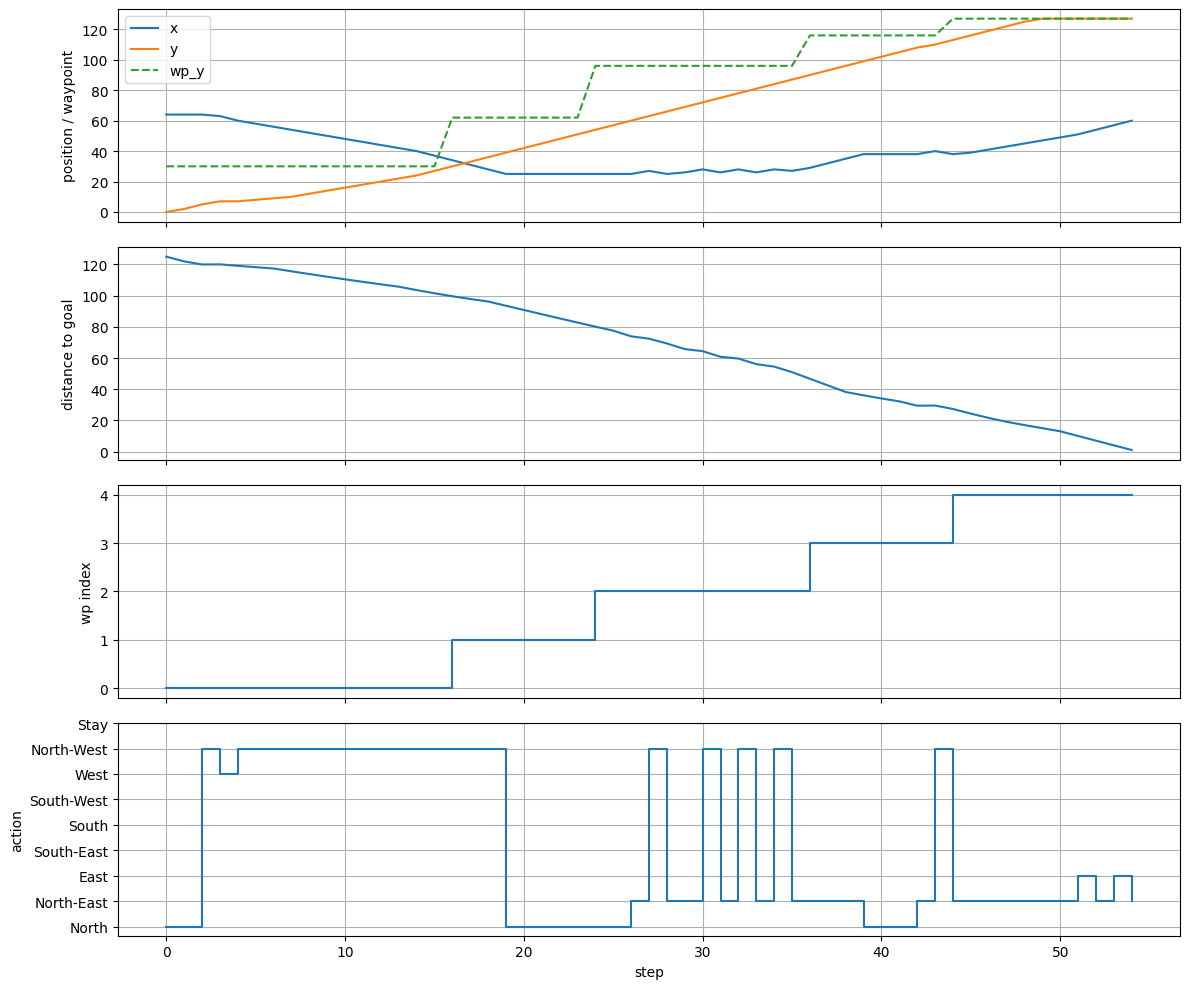

In [14]:

def build_episode_dataframe(trajectory, actions, rewards, infos, extra=None):
    rows = []

    waypoint_indices = extra.get("waypoint_indices", []) if extra else []
    waypoint_targets = extra.get("waypoint_targets", []) if extra else []

    for t, action in enumerate(actions):
        pos = trajectory[t]
        next_pos = trajectory[t + 1]
        info = infos[t] if t < len(infos) else {}

        wp_index = waypoint_indices[t] if t < len(waypoint_indices) else np.nan
        wp_target = waypoint_targets[t] if t < len(waypoint_targets) else np.array([np.nan, np.nan])

        rows.append({
            "step": t,
            "x": float(pos[0]),
            "y": float(pos[1]),
            "next_x": float(next_pos[0]),
            "next_y": float(next_pos[1]),
            "action": int(action),
            "action_name": ACTION_NAMES[int(action)],
            "reward": float(rewards[t]),
            "distance_to_goal": float(info.get("distance_to_goal", np.nan)),
            "is_stuck": bool(info.get("is_stuck", False)),
            "wp_index": wp_index,
            "wp_x": float(wp_target[0]),
            "wp_y": float(wp_target[1]),
        })

    return pd.DataFrame(rows)


episode_df = build_episode_dataframe(trajectory, actions, rewards, infos, extra=extra)
display(episode_df.head())
display(episode_df.tail())

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(episode_df["step"], episode_df["x"], label="x")
axes[0].plot(episode_df["step"], episode_df["y"], label="y")
axes[0].plot(episode_df["step"], episode_df["wp_y"], linestyle="--", label="wp_y")
axes[0].set_ylabel("position / waypoint")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(episode_df["step"], episode_df["distance_to_goal"])
axes[1].set_ylabel("distance to goal")
axes[1].grid(True)

axes[2].step(episode_df["step"], episode_df["wp_index"], where="post")
axes[2].set_ylabel("wp index")
axes[2].grid(True)

axes[3].step(episode_df["step"], episode_df["action"], where="post")
axes[3].set_ylabel("action")
axes[3].set_xlabel("step")
axes[3].set_yticks(list(ACTION_NAMES.keys()))
axes[3].set_yticklabels([ACTION_NAMES[k] for k in ACTION_NAMES])
axes[3].grid(True)

plt.tight_layout()
plt.show()


## 14. Comparer gauche / droite sur un scénario

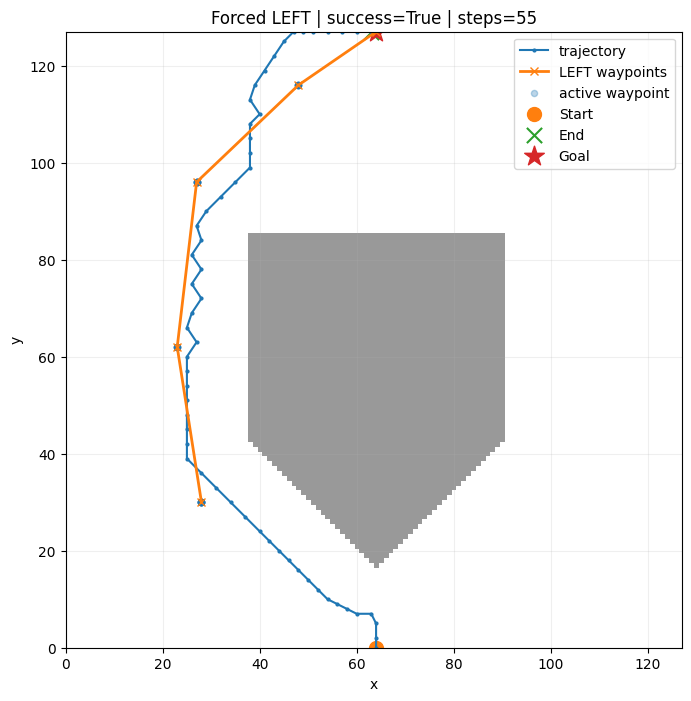

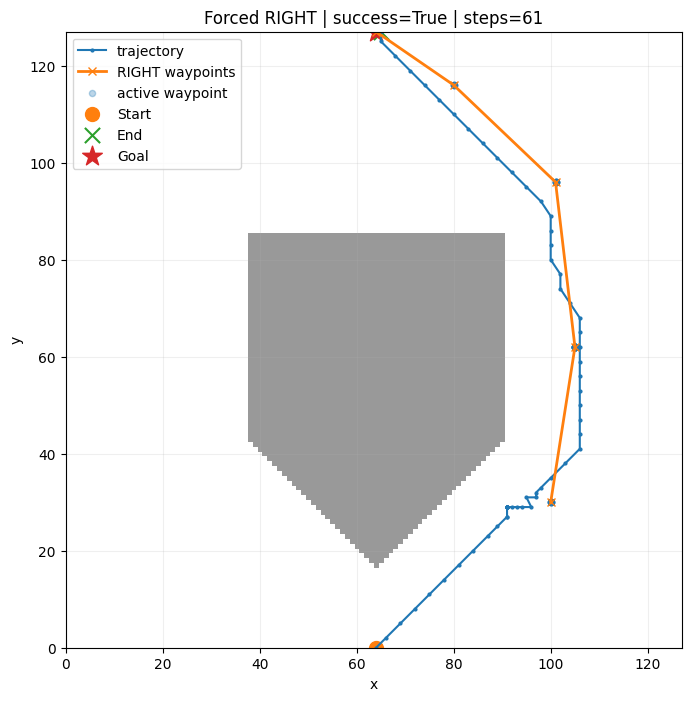

,scenario,seed,side,success,steps,discounted_score,is_stuck,final_position
0,training_1,0,LEFT,True,55,75.904835,False,"[63, 127]"
1,training_1,0,RIGHT,True,61,73.655965,False,"[65, 127]"


In [15]:

comparison_rows = []

for forced_side in ["LEFT", "RIGHT"]:
    result_side, trajectory_side, actions_side, rewards_side, infos_side, env_side, extra_side = run_waypoint_episode(
        scenario_name="training_1",
        seed=0,
        horizon=2,
        wp_radius=12.0,
        static_wind=True,
        force_side=forced_side,
    )
    comparison_rows.append(result_side)

    plot_waypoint_trajectory(
        trajectory_side,
        env_side,
        side=forced_side,
        extra=extra_side,
        title=f"Forced {forced_side} | success={result_side['success']} | steps={result_side['steps']}",
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df[["scenario", "seed", "side", "success", "steps", "discounted_score", "is_stuck", "final_position"]])


## 15. Évaluation multi-seeds / multi-scénarios

Attention : cette version utilise `copy.deepcopy(env)` pour le planning, donc elle est plus lente.  
On commence volontairement avec peu de seeds.


In [16]:

def evaluate_waypoint_strategy(
    scenarios=None,
    seeds=None,
    horizon=2,
    wp_radius=12.0,
    static_wind=True,
):
    if scenarios is None:
        scenarios = list(WIND_SCENARIOS.keys())

    if seeds is None:
        seeds = range(5)

    rows = []

    for scenario_name in scenarios:
        for seed in seeds:
            result, trajectory, actions, rewards, infos, env_run, extra = run_waypoint_episode(
                scenario_name=scenario_name,
                seed=seed,
                horizon=horizon,
                wp_radius=wp_radius,
                static_wind=static_wind,
            )

            rows.append(result)

            print(
                f"{scenario_name} seed={seed:02d} "
                f"side={result['side']:5s} "
                f"success={result['success']} "
                f"steps={result['steps']:3d} "
                f"score={result['discounted_score']:.2f} "
                f"stuck={result['is_stuck']}"
            )

    return pd.DataFrame(rows)


eval_df = evaluate_waypoint_strategy(
    scenarios=list(WIND_SCENARIOS.keys()),
    seeds=range(3),
    horizon=2,
    wp_radius=12.0,
    static_wind=True,
)

display(eval_df)

summary = (
    eval_df
    .groupby("scenario")
    .agg(
        success_rate=("success", "mean"),
        avg_steps=("steps", "mean"),
        avg_score=("discounted_score", "mean"),
        stuck_rate=("is_stuck", "mean"),
    )
    .reset_index()
)

display(summary)


training_1 seed=00 side=LEFT  success=True steps= 55 score=75.90 stuck=False
training_1 seed=01 side=LEFT  success=True steps= 56 score=75.53 stuck=False
training_1 seed=02 side=LEFT  success=True steps= 56 score=75.53 stuck=False
training_2 seed=00 side=RIGHT success=True steps= 45 score=79.81 stuck=False
training_2 seed=01 side=RIGHT success=True steps= 45 score=79.81 stuck=False
training_2 seed=02 side=RIGHT success=True steps= 45 score=79.81 stuck=False
training_3 seed=00 side=LEFT  success=True steps= 91 score=63.37 stuck=False
training_3 seed=01 side=RIGHT success=True steps= 44 score=80.21 stuck=False
training_3 seed=02 side=RIGHT success=True steps= 43 score=80.61 stuck=False


,scenario,seed,horizon,side,wp_radius,steps,reward_sum,discounted_score,success,terminated,truncated,is_stuck,final_position,side_info
0,training_1,0,2,LEFT,12.0,55,100.0,75.904835,True,True,False,False,"[63, 127]","{'left_score': -0.875526487082243, 'right_scor..."
1,training_1,1,2,LEFT,12.0,56,100.0,75.525311,True,True,False,False,"[63, 127]","{'left_score': -1.4982833743095398, 'right_sco..."
2,training_1,2,2,LEFT,12.0,56,100.0,75.525311,True,True,False,False,"[63, 127]","{'left_score': -1.5726787567138674, 'right_sco..."
3,training_2,0,2,RIGHT,12.0,45,100.0,79.806568,True,True,False,False,"[63, 126]","{'left_score': -7.470267820358276, 'right_scor..."
4,training_2,1,2,RIGHT,12.0,45,100.0,79.806568,True,True,False,False,"[64, 126]","{'left_score': -7.2611288070678714, 'right_sco..."
5,training_2,2,2,RIGHT,12.0,45,100.0,79.806568,True,True,False,False,"[64, 127]","{'left_score': -7.4288569688797, 'right_score'..."
6,training_3,0,2,LEFT,12.0,91,100.0,63.372428,True,True,False,False,"[63, 127]","{'left_score': 9.11078417301178, 'right_score'..."
7,training_3,1,2,RIGHT,12.0,44,100.0,80.207606,True,True,False,False,"[64, 127]","{'left_score': 8.891892194747925, 'right_score..."
8,training_3,2,2,RIGHT,12.0,43,100.0,80.610659,True,True,False,False,"[63, 127]","{'left_score': 8.771293115615844, 'right_score..."


,scenario,success_rate,avg_steps,avg_score,stuck_rate
0,training_1,1.0,55.666667,75.651819,0.0
1,training_2,1.0,45.000000,79.806568,0.0
2,training_3,1.0,59.333333,74.730231,0.0


## 16. Tester quelques paramètres simples

Ici, on teste une petite grille : `horizon` et `wp_radius`.  
Le vrai tuning complet sera fait dans `04_parameter_tuning.ipynb`.


In [17]:

tuning_rows = []

for horizon in [1, 2]:
    for wp_radius in [10.0, 14.0]:
        print("\n" + "=" * 80)
        print("horizon =", horizon, "| wp_radius =", wp_radius)

        df = evaluate_waypoint_strategy(
            scenarios=["training_1"],
            seeds=range(3),
            horizon=horizon,
            wp_radius=wp_radius,
            static_wind=True,
        )

        tuning_rows.append({
            "horizon": horizon,
            "wp_radius": wp_radius,
            "success_rate": df["success"].mean(),
            "avg_steps": df["steps"].mean(),
            "avg_score": df["discounted_score"].mean(),
            "stuck_rate": df["is_stuck"].mean(),
        })

tuning_df = pd.DataFrame(tuning_rows).sort_values(
    ["success_rate", "avg_score", "avg_steps"],
    ascending=[False, False, True],
)

display(tuning_df)



horizon = 1 | wp_radius = 10.0
training_1 seed=00 side=LEFT  success=True steps= 56 score=75.53 stuck=False
training_1 seed=01 side=LEFT  success=True steps= 57 score=75.15 stuck=False
training_1 seed=02 side=LEFT  success=False steps=500 score=0.00 stuck=False

horizon = 1 | wp_radius = 14.0
training_1 seed=00 side=LEFT  success=True steps= 56 score=75.53 stuck=False
training_1 seed=01 side=LEFT  success=True steps= 57 score=75.15 stuck=False
training_1 seed=02 side=LEFT  success=False steps=500 score=0.00 stuck=False

horizon = 2 | wp_radius = 10.0
training_1 seed=00 side=LEFT  success=True steps= 55 score=75.90 stuck=False
training_1 seed=01 side=LEFT  success=True steps= 56 score=75.53 stuck=False
training_1 seed=02 side=LEFT  success=True steps= 56 score=75.53 stuck=False

horizon = 2 | wp_radius = 14.0
training_1 seed=00 side=LEFT  success=True steps= 55 score=75.90 stuck=False
training_1 seed=01 side=LEFT  success=True steps= 55 score=75.90 stuck=False
training_1 seed=02 side=L

,horizon,wp_radius,success_rate,avg_steps,avg_score,stuck_rate
3,2,14.0,1.000000,55.333333,75.778327,0.0
2,2,10.0,1.000000,55.666667,75.651819,0.0
0,1,10.0,0.666667,204.333333,50.224332,0.0
1,1,14.0,0.666667,204.333333,50.224332,0.0


## 17. Notes importantes pour la suite

Ce notebook valide la logique waypoint en utilisant l'environnement réel du dépôt.

Pour Codabench :
- ne pas embarquer `SailingEnv` dans `my_agent.py` ;
- ne pas utiliser `copy.deepcopy(env)` dans `act` ;
- utiliser plutôt une simulation interne légère, comme dans le notebook `04_parameter_tuning.ipynb`.

Le prochain notebook utilisera cette idée de waypoints pour générer et tuner un vrai agent soumettable.
